 transition_plots.py
  Demographic inflection year: 2007.0
  Configuration A: single-fit a=1.25 (1895-2020)
  Configuration B: B1 (a=1.478, 1895-1970) + B2 (a=0.655, 1970-2020)

[1/5] Consensus regime — t=45 (1940) vs t=112 (2007)...


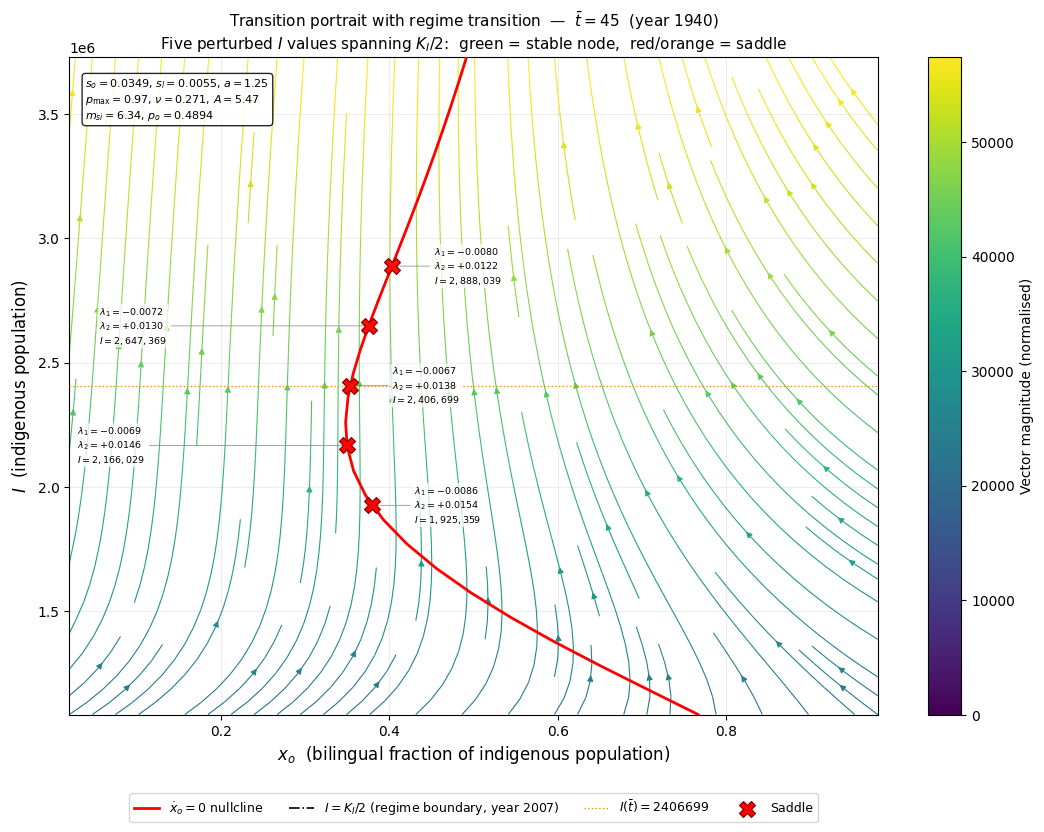

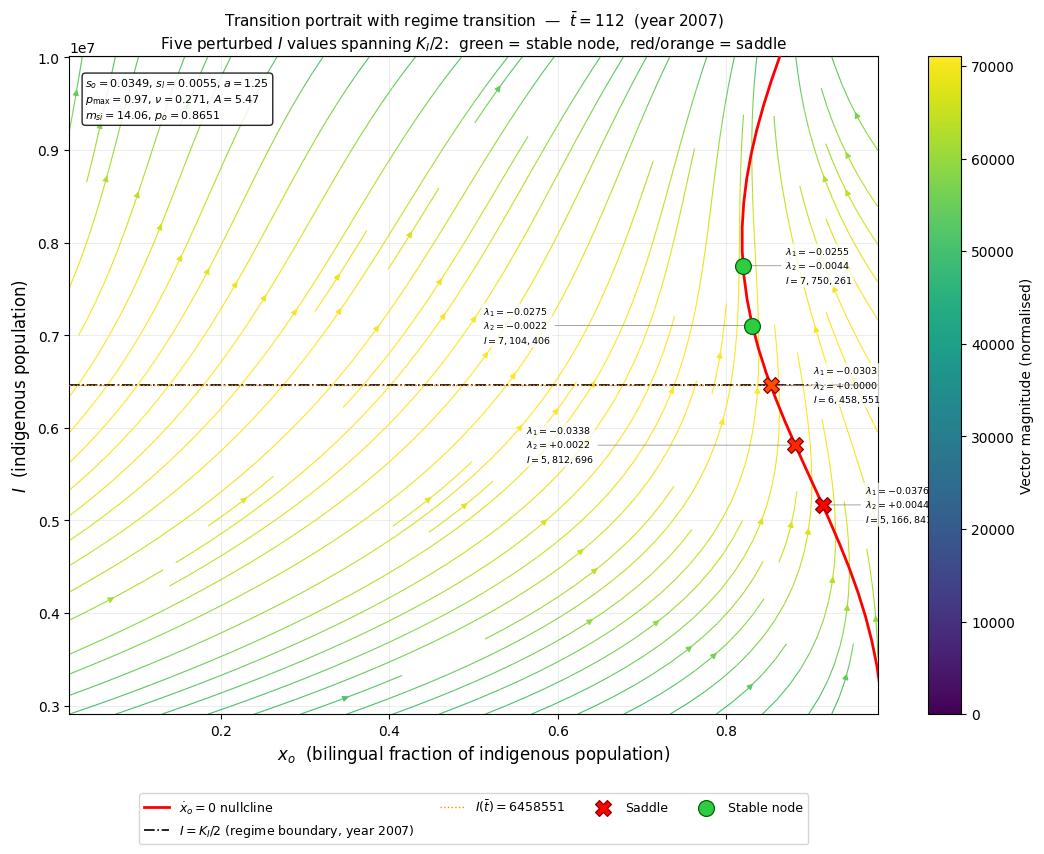

      Saved: transition_consensus_t45.jpg / t112.jpg

[2/5] Coexistence regime — t=95 (1990) vs t=112 (2007)...


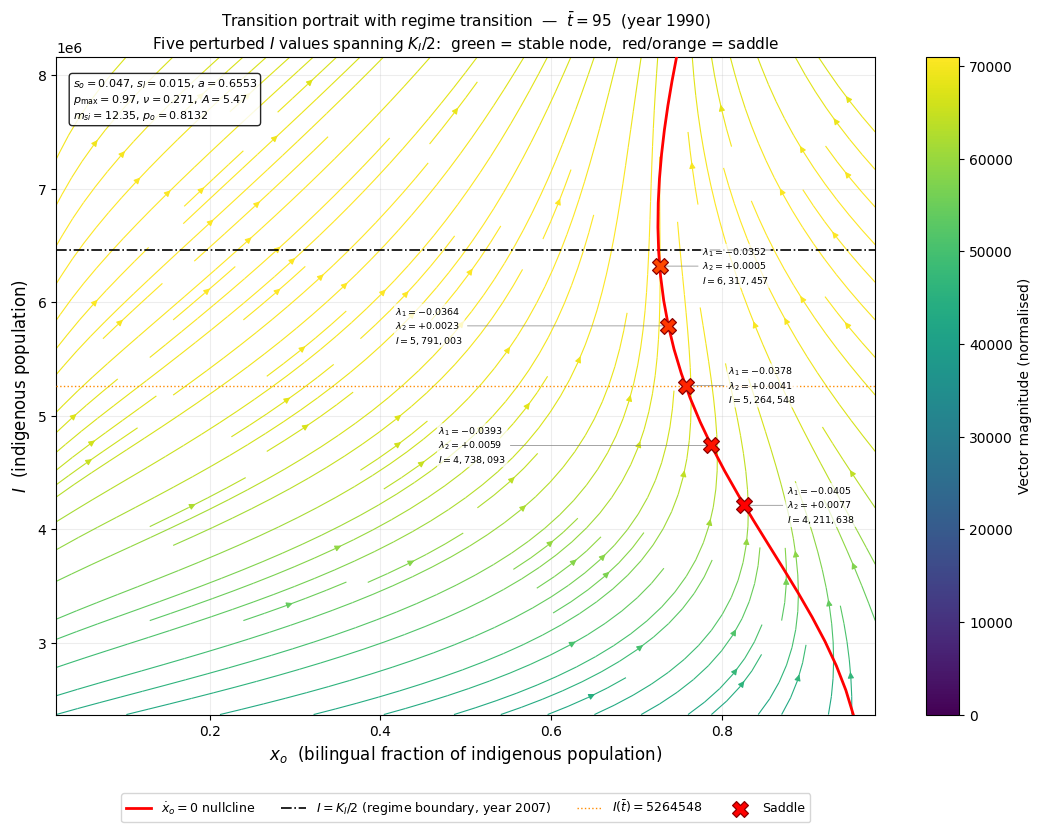

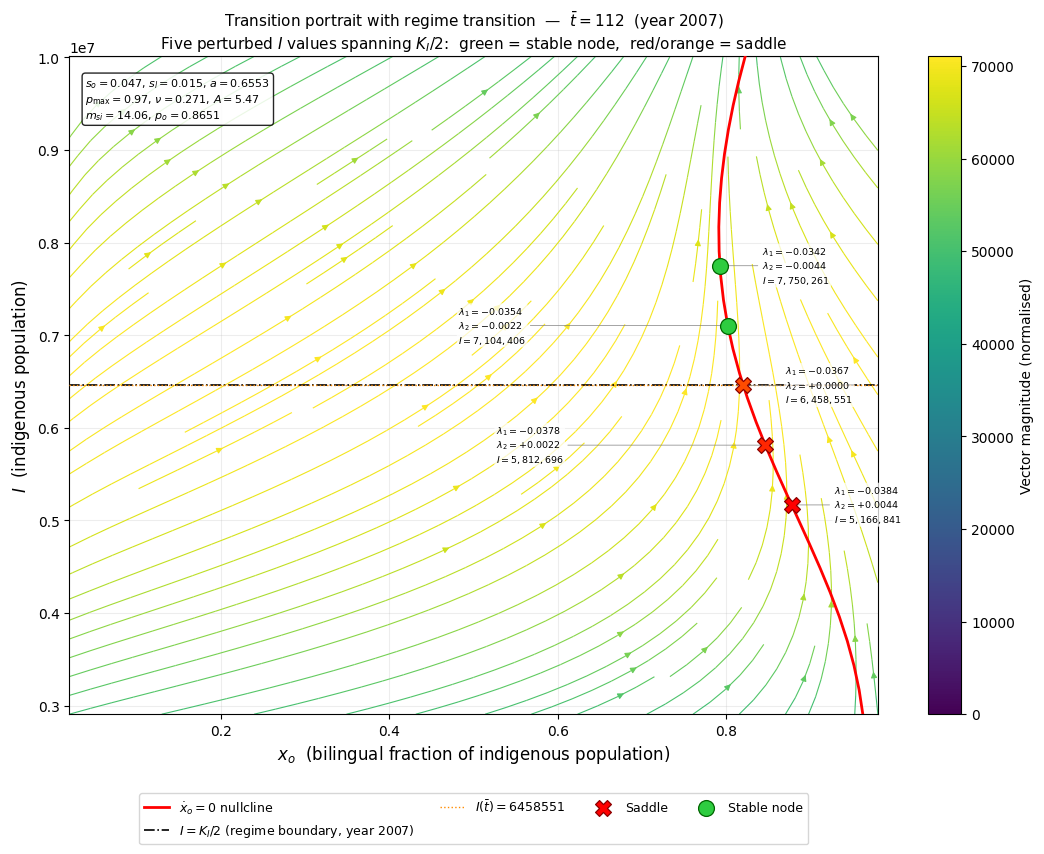

      Saved: transition_coexistence_t95.jpg / t112.jpg

[3/5] Dual-regime f/f+g (A, B1, B2) — t=75 (year 1970)...


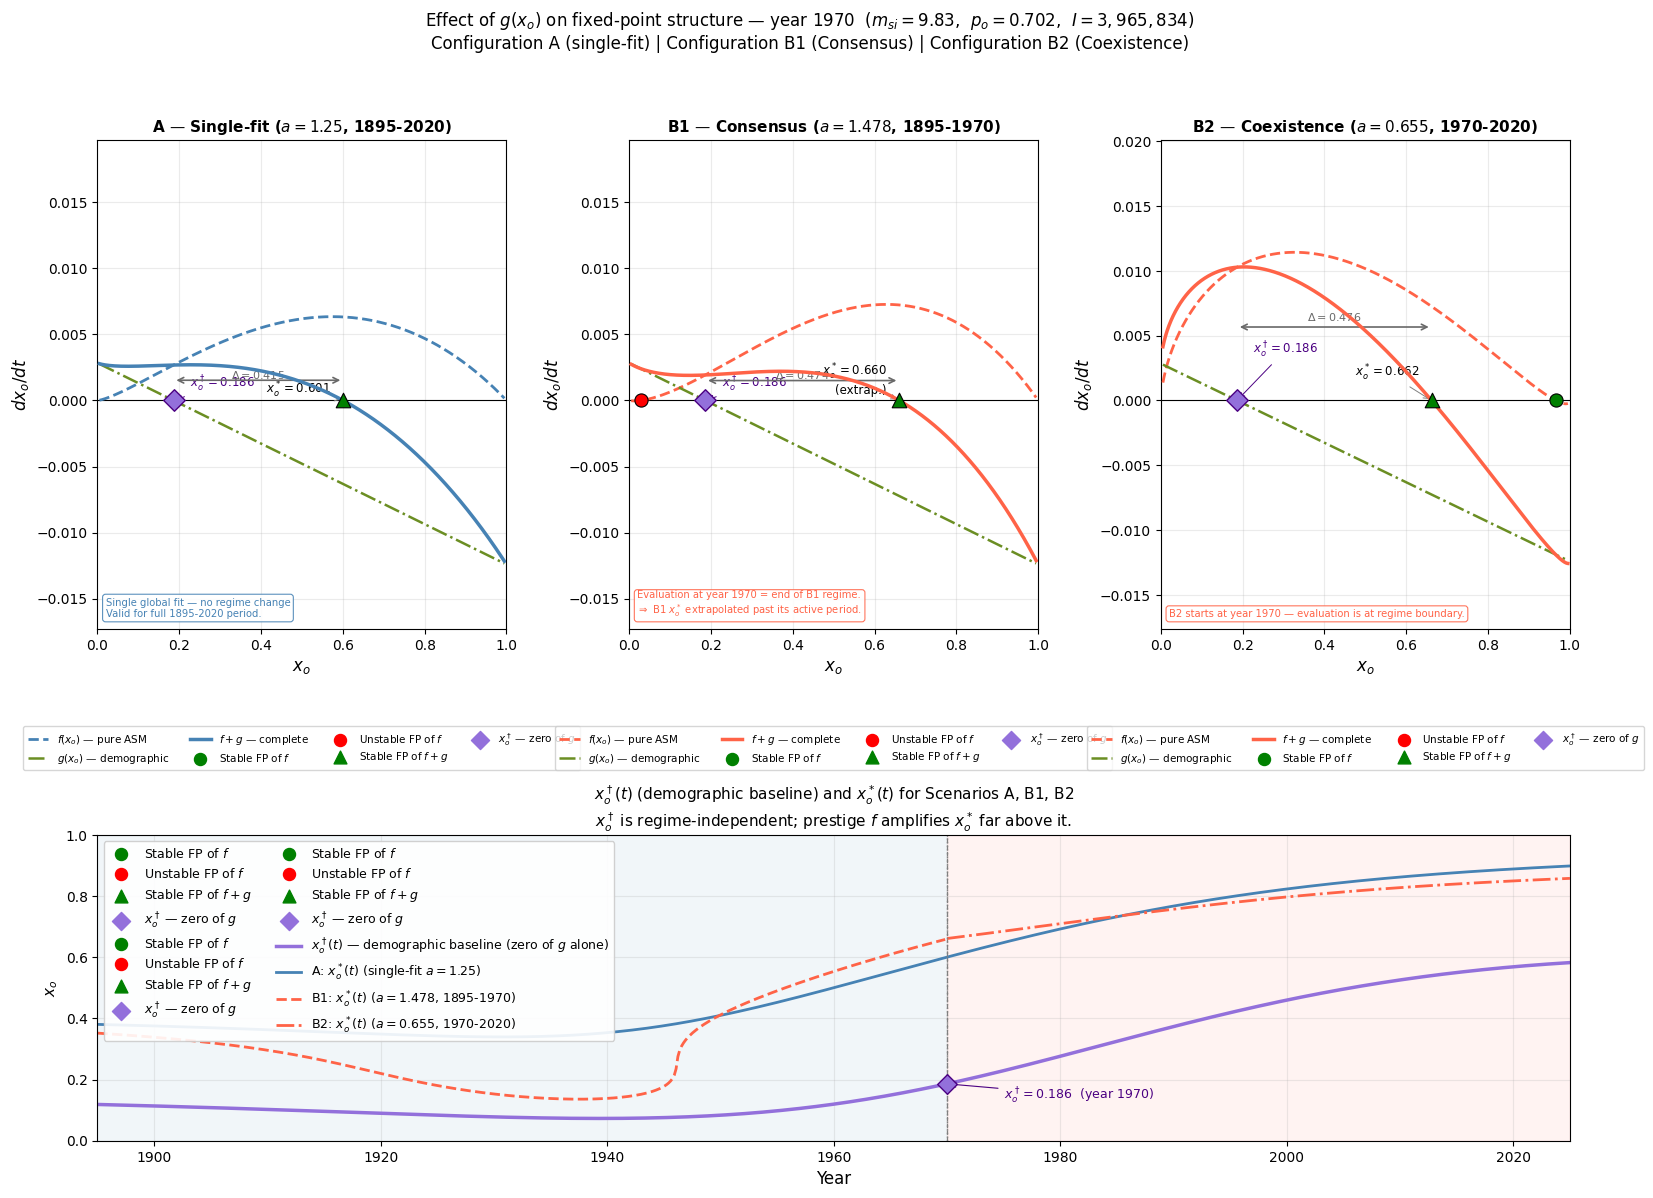

      Saved: dual_regime_comparison.jpg

[4/5] Fixed point evolution x_o*(t) — Configurations A, B1, B2...
      Computing Configuration A FP series...
      Computing Configuration B FP series...


/tmp/ipykernel_25839/627537403.py:1204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


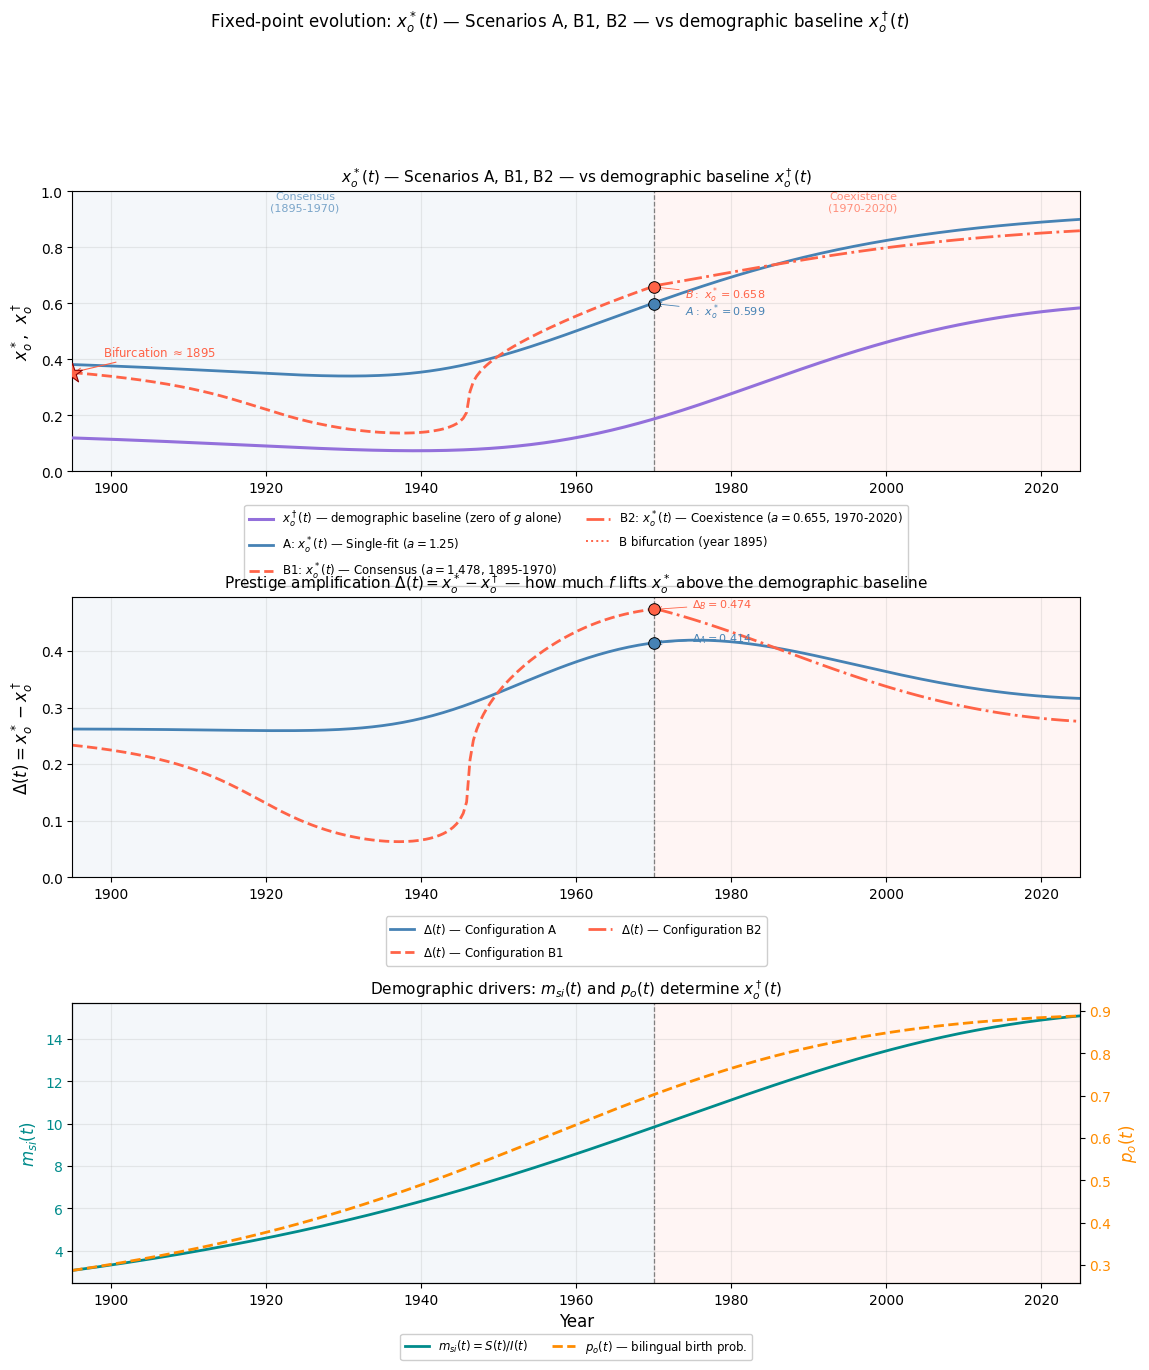

      Saved: fp_evolution.jpg

[5/5] Closing synthesis figure (census + theory + J00)...
      [closing] Configuration A x_o*(t)...
      [closing] Configuration B x_o*(t)...


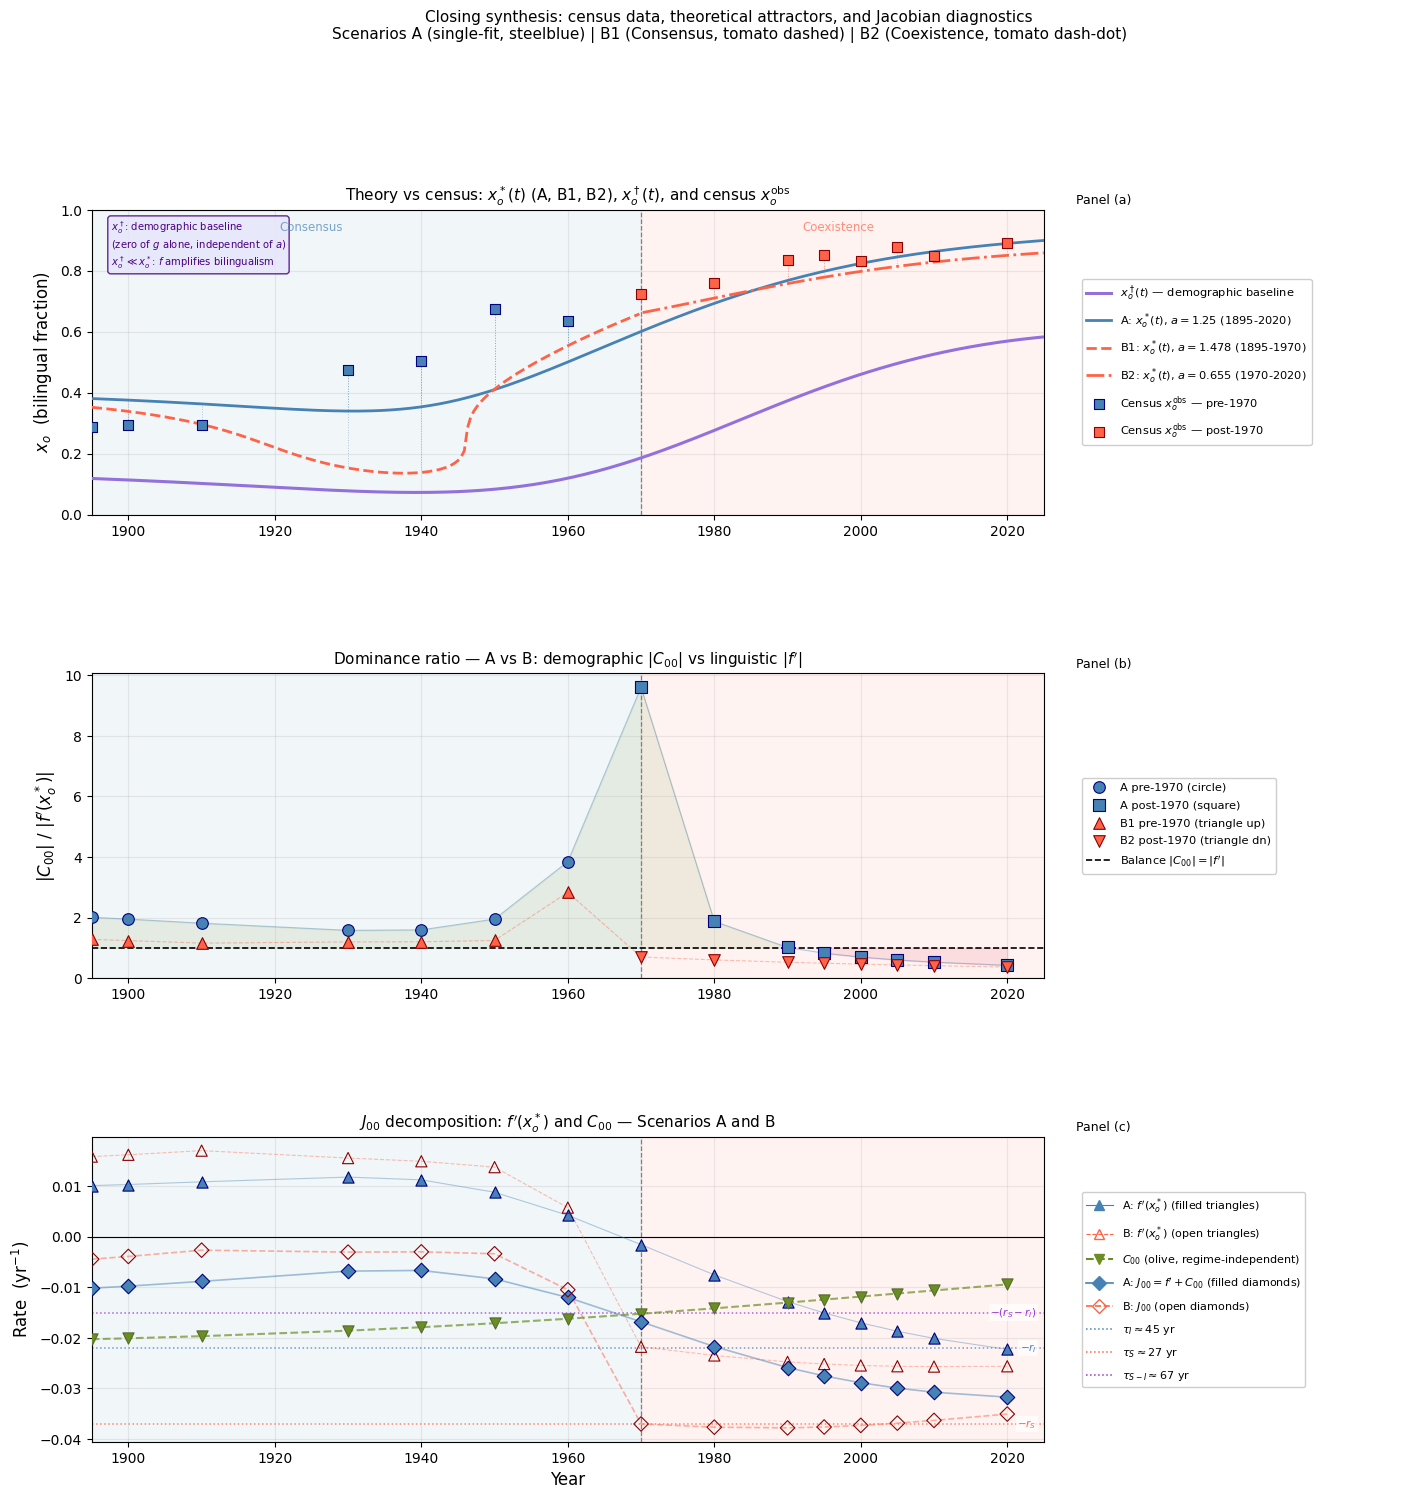

      Saved: closing_figure.jpg

 All plots generated successfully!


In [16]:
"""
20 Feb 2026
transition_plots.py
====================
Generates two key diagnostic plots for the extended Abrams-Strogatz model:

PLOT 1 — Transition vector field
    Shows how the fixed point classification changes from saddle to stable node
    as the indigenous population I crosses the logistic inflection point K_I/2.
    We perturb I around year 2007 (when I ≈ K_I/2) and plot 5 fixed points
    simultaneously to visualize the red→green transition.

PLOT 2 — Dual-regime comparison
    Compares the effect of the demographic term g(x_o) in two historical periods:
      - Consensus (a=1.25, 1895-1970): g creates a stable interior fixed point
      - Coexistence (a=0.655, 1970-2020): g shifts an existing stable fixed point
    
    Shows f(x_o) [ASM alone] vs f(x_o)+g(x_o) [complete system] at year 1970.

Author: Riccardo Del Gratta, with Claude assistance
Date: February 2025
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.optimize import brentq
import warnings

# ===========================================================================
# MODEL PARAMETERS
# ===========================================================================
# These are calibrated from Mexican census data (1895-2020)

# Indigenous population logistic growth
N0_indigenous = 1012848      # Initial population at t=0 (year 1895)
K_indigenous = 12918933      # Carrying capacity
r_indigenous = 0.022         # Growth rate (yr^-1)

# Spanish population logistic growth
N0_spanish = 3117878         # Initial population at t=0
K_spanish = 165995301        # Carrying capacity
r_spanish = 0.037            # Growth rate (yr^-1)

# Bilingual birth probability parameters
A_p = 5.47                   # Sigmoid shape parameter
nu = 0.271                   # Sensitivity to m_si ratio
p_max = 0.97                 # Maximum probability

# ---------------------------------------------------------------------------
# THREE SCENARIOS  (mirrors language_dynamics_extended_v5.py)
# ---------------------------------------------------------------------------
#
# Configuration A  — single global fit, whole period 1895-2020
#   Parameters from empirical fit to all census data; no regime change.
S_O_CONS_ALL = 0.0349;  S_L_CONS_ALL = 0.0055;  A_CONS_ALL = 1.25
#
# Configuration B  — dual-regime
#   B1: Consensus  1895-1970  (analytically derived new-consensus parameters)
S_O_CONS = 0.0454;  S_L_CONS = 0.00839;  A_CONS = 1.478
#   B2: Coexistence 1970-2020  (same for both B and, post-1970, A and B)
S_O_COEX = 0.047;   S_L_COEX = 0.015;   A_COEX = 0.6553

T_REGIME_CHANGE = 75.0   # t = year 1970

# Legacy lowercase aliases — kept so all existing helper functions that
# reference s_o_cons / s_o_coex etc. continue to work without modification.
# They now point to Configuration A (single-fit) for Consensus and the shared
# Coexistence block for the post-1970 period.
s_o_cons = S_O_CONS_ALL;  s_l_cons = S_L_CONS_ALL;  a_cons = A_CONS_ALL
s_o_coex = S_O_COEX;      s_l_coex = S_L_COEX;      a_coex = A_COEX

base_year = 1895             # Reference year (t=0)

# ---------------------------------------------------------------------------
# Scenario registry  (plot style + parameter sets)
# ---------------------------------------------------------------------------
SCENARIOS = {
    'A': {
        'label'     : 'A: Single-fit ($a=1.25$, 1895-2020)',
        'label_pre' : 'A (1895-1970, $a=1.25$)',
        'label_post': 'A (1970-2020, $a=1.25$)',
        'color': 'steelblue', 'ls': '-',
        'cons': dict(s_o=S_O_CONS_ALL, s_l=S_L_CONS_ALL, a=A_CONS_ALL),
        'coex': dict(s_o=S_O_CONS_ALL, s_l=S_L_CONS_ALL, a=A_CONS_ALL),
        'dual': False,
    },
    'B': {
        'label'     : 'B: Dual-regime (B1 $a=1.478$ / B2 $a=0.655$)',
        'label_pre' : 'B1: Consensus ($a=1.478$, 1895-1970)',
        'label_post': 'B2: Coexistence ($a=0.655$, 1970-2020)',
        'color': 'tomato', 'ls': '--',
        'cons': dict(s_o=S_O_CONS, s_l=S_L_CONS, a=A_CONS),
        'coex': dict(s_o=S_O_COEX, s_l=S_L_COEX, a=A_COEX),
        'dual': True,
    },
}


def scenario_params(t, scenario='A'):
    """
    Return (s_o, s_l, a, label) for the given scenario at time t.

    Parameters
    ----------
    t        : float  years since base_year (1895)
    scenario : str    'A' or 'B'
    """
    sc = SCENARIOS[scenario]
    if t < T_REGIME_CHANGE:
        p   = sc['cons']
        lbl = sc['label_pre']
    else:
        p   = sc['coex']
        lbl = sc['label_post']
    return p['s_o'], p['s_l'], p['a'], lbl

# ===========================================================================
# COMPUTE THE TRANSITION YEAR (when I = K_I/2)
# ===========================================================================
# This is the year when J11 = r_I(1 - 2I/K_I) changes sign from + to -.
# It's purely demographic — the inflection point of the logistic curve for I(t).

T_CROSS = brentq(
    # This anonymous function computes I(t) - K_I/2
    # We're finding the time t where this equals zero
    lambda t: K_indigenous / (1 + ((K_indigenous-N0_indigenous)/N0_indigenous)
                               * np.exp(-r_indigenous*t)) - K_indigenous/2,
    0, 300  # Search between t=0 and t=300 years
)
YEAR_CROSS = base_year + T_CROSS  # Convert to calendar year


# ===========================================================================
# CORE MATHEMATICAL FUNCTIONS
# ===========================================================================

def logistic(t, K, r, N0):
    """
    Standard logistic growth function: N(t) = K / (1 + C*exp(-rt))
    where C = (K-N0)/N0 is determined by the initial condition.
    
    Parameters
    ----------
    t : float
        Time since base_year (years)
    K : float
        Carrying capacity (maximum population)
    r : float
        Growth rate (yr^-1)
    N0 : float
        Initial population at t=0
        
    Returns
    -------
    float
        Population at time t
        
    Notes
    -----
    The inflection point (maximum growth rate) occurs at N = K/2, which
    corresponds to time t* = (1/r) * ln(C) where C = (K-N0)/N0.
    """
    return K / (1 + ((K-N0)/N0)*np.exp(-r*t))


def p_o_func(m):
    """
    Probability that a newborn indigenous individual is bilingual.
    
    This is a sigmoid function of the Spanish-to-indigenous ratio m_si = S/I.
    As m_si increases (more Spanish speakers per indigenous speaker), the
    probability of being born bilingual increases, saturating at p_max.
    
    Parameters
    ----------
    m : float
        Spanish-to-indigenous ratio m_si = S(t)/I(t)
        
    Returns
    -------
    float
        Probability p_o ∈ (0, p_max)
        
    Formula
    -------
    p_o(m) = p_max / (1 + A * exp(-ν * m))
    
    This is a logistic (sigmoid) function:
    - When m → 0 (few Spanish speakers): p_o → 0
    - When m → ∞ (many Spanish speakers): p_o → p_max
    - The parameter ν controls how sensitive p_o is to changes in m
    """
    return p_max / (1 + A_p*np.exp(-nu*m))


def f_func(x_o, s_o, s_l, a):
    """
    Abrams-Strogatz prestige function.
    
    This encodes linguistic conversions (Monolingual ↔ Bilingual) driven by
    prestige differences. It's the "internal dynamics" of the ASM model,
    evaluated at constant population.
    
    Parameters
    ----------
    x_o : float or array
        Bilingual fraction of indigenous population (0 ≤ x_o ≤ 1)
    s_o : float
        Prestige of Spanish language
    s_l : float
        Prestige of indigenous language
    a : float
        Volatility parameter
        
    Returns
    -------
    float or array
        Rate of change dx_o/dt from ASM dynamics alone
        
    Formula
    -------
    f(x_o) = s_o * x_o^a * (1-x_o) - s_l * (1-x_o)^a * x_o
    
    The two terms represent:
    - First term: Monolinguals (fraction 1-x_o) becoming bilingual
    - Second term: Bilinguals (fraction x_o) reverting to monolingual
    
    Fixed points occur where f(x_o) = 0:
    - Always at x_o=0 and x_o=1 (boundary fixed points)
    - Interior fixed point at x_o* = 1/(1+β) where β = (s_o/s_l)^(1/(a-1))
    
    Stability of interior fixed point:
    - If a > 1: interior is UNSTABLE (repels trajectories)
    - If a < 1: interior is STABLE (attracts trajectories)
    
    Notes
    -----
    We handle boundaries carefully to avoid power-law singularities when a < 1.
    The exponents a-1 and a-2 in the derivative can be negative, causing
    division-by-zero at x_o=0 or x_o=1.
    """
    # Scalar case (single x_o value)
    if np.ndim(x_o) == 0:
        if x_o <= 0 or x_o >= 1:
            return 0.0  # Zero at boundaries (no change possible)
        # Suppress RuntimeWarning from negative exponents
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            return s_o*(x_o**a)*(1-x_o) - s_l*((1-x_o)**a)*x_o
    
    # Array case (multiple x_o values for plotting)
    else:
        x = np.asarray(x_o, dtype=float)
        out = np.zeros_like(x)
        # Only compute where 0 < x < 1 (interior)
        mask = (x > 0) & (x < 1)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            out[mask] = s_o*(x[mask]**a)*(1-x[mask]) - s_l*((1-x[mask])**a)*x[mask]
        return out


def g_func(x_o, p, m_val, I, s_o, s_l, a):
    """
    Natural increment function: demographic contribution to dx_o/dt.
    
    This term captures the effect of population growth on the bilingual fraction.
    It has three components (derived via quotient rule):
      1. New bilingual births at rate p_o * (dI/dt)
      2. Evolution of p_o itself as m_si changes
      3. Quotient-rule correction from x_o = X_o/I
    
    Parameters
    ----------
    x_o : float
        Bilingual fraction
    p : float
        Bilingual birth probability p_o(m_si)
    m_val : float
        Spanish-to-indigenous ratio m_si = S/I
    I : float
        Indigenous population
    s_o, s_l, a : float
        ASM parameters (not used here, kept for API consistency)
        
    Returns
    -------
    float
        Contribution to dx_o/dt from demographic processes
        
    Formula
    -------
    g(x_o, I) = [p_o - x_o - p_o(1-p_o/p_max)νm_si] * r_I(1 - I/K_I)
    
    The bracket combines three effects:
    - p_o: injection of new bilingual births
    - -x_o: quotient rule correction (denominator I growing)
    - -p_o(1-p_o/p_max)νm_si: evolution of p_o as I changes
    
    The factor r_I(1-I/K_I) is dI/dt / I (logistic growth rate per capita).
    """
    # The bracket [p_o - x_o - ...]
    bracket = p - x_o - p*(1-p/p_max)*nu*m_val
    
    # Logistic growth factor: (1/I) * dI/dt = r_I(1 - I/K_I)
    logistic_factor = r_indigenous*(1 - I/K_indigenous)
    
    return bracket * logistic_factor


def rhs(x_o, I, S, s_o, s_l, a):
    """
    Full right-hand side of the extended model equation.
    
    This computes dx_o/dt = f(x_o) + g(x_o, I, S) for given (x_o, I, S).
    
    Parameters
    ----------
    x_o : float
        Bilingual fraction
    I : float
        Indigenous population
    S : float
        Spanish population (held fixed in quasi-static approximation)
    s_o, s_l, a : float
        ASM parameters for the chosen regime
        
    Returns
    -------
    float
        Total rate of change dx_o/dt
        
    Notes
    -----
    Fixed points of the system satisfy rhs(x_o*, I, S) = 0.
    The stability is determined by the Jacobian eigenvalues:
      λ₁ = ∂rhs/∂x_o = J00  (x_o-direction)
      λ₂ = ∂(dI/dt)/∂I = J11 = r_I(1 - 2I/K_I)  (I-direction)
    """
    # Compute derived quantities
    m_val = S/I if I > 0 else np.inf
    p = p_o_func(m_val)
    
    # Sum ASM term + demographic term
    return f_func(x_o, s_o, s_l, a) + g_func(x_o, p, m_val, I, s_o, s_l, a)


def find_fp(I_val, S_val, s_o, s_l, a, n=3000):
    """
    Find all fixed points x_o* at given (I, S) values.
    
    Strategy: scan for sign changes, then refine with Brent's method.
    This is robust even when the function has multiple roots or nearly
    touches zero without crossing.
    
    Parameters
    ----------
    I_val, S_val : float
        Population values at which to find fixed points
    s_o, s_l, a : float
        ASM parameters
    n : int
        Number of scan points (higher = more reliable root detection)
        
    Returns
    -------
    list of float
        All fixed points x_o* ∈ (0,1) where rhs(x_o*, I_val, S_val) = 0
        
    Algorithm
    ---------
    1. Evaluate rhs on a dense grid [0.005, 0.995]
    2. Find intervals where sign changes (indicates a root)
    3. For each sign change, use Brent's method to refine the root
    
    Why Brent's method?
    - Guaranteed convergence when bracketed by sign change
    - No need for derivative (unlike Newton)
    - Robust to singularities at boundaries
    """
    # Dense scan grid
    xs = np.linspace(0.005, 0.995, n)
    
    # Evaluate rhs at all grid points
    vals = np.array([rhs(x, I_val, S_val, s_o, s_l, a) for x in xs])
    
    # Find where sign changes (indicates root between consecutive points)
    sign_changes = np.where(np.diff(np.sign(vals)))[0]
    
    roots = []
    for idx in sign_changes:
        try:
            # Brent's method: finds root in interval [xs[idx], xs[idx+1]]
            xr = brentq(
                lambda x: rhs(x, I_val, S_val, s_o, s_l, a),
                xs[idx], xs[idx+1],
                xtol=1e-10  # Tolerance: root accuracy to 10 decimal places
            )
            roots.append(xr)
        except Exception:
            # If Brent fails (shouldn't happen with sign change), skip
            pass
    
    return roots


def classify(x_o, I_val, S_val, s_o, s_l, a, eps=1e-6):
    """
    Classify a fixed point by computing J00 and J11.
    
    The Jacobian of the system is upper-triangular:
    
        J = [ J00  J01 ]
            [  0   J11 ]
    
    Eigenvalues are λ₁=J00 (x_o direction) and λ₂=J11 (I direction).
    
    Classification:
      - Both negative → Stable node (attracts in all directions)
      - One negative, one positive → Saddle (attracts in one dir, repels in other)
      - Both positive → Unstable node (repels in all directions)
    
    Parameters
    ----------
    x_o : float
        Fixed point x_o-coordinate
    I_val, S_val : float
        Population values at fixed point
    s_o, s_l, a : float
        ASM parameters
    eps : float
        Finite difference step size
        
    Returns
    -------
    fully_stable : bool
        True if stable node (both eigenvalues negative)
    saddle : bool
        True if saddle (eigenvalues of opposite signs)
    J00 : float
        Eigenvalue in x_o direction
    J11 : float
        Eigenvalue in I direction
        
    Notes
    -----
    We compute J00 numerically because the analytical derivative has
    power-law singularities when a < 1.
    
    J11 is computed analytically from the logistic equation:
        dI/dt = r_I * I * (1 - I/K_I)
        ⟹ ∂(dI/dt)/∂I = r_I(1 - 2I/K_I)
    
    This changes sign at I = K_I/2 (the logistic inflection point).
    """
    # Compute derived quantities at the fixed point
    m_val = S_val/I_val
    p = p_o_func(m_val)
    
    # --- Compute J00 numerically using centered finite differences ---
    # J00 = ∂rhs/∂x_o evaluated at (x_o, I_val, S_val)
    
    # Perturb x_o by ±eps, staying away from boundaries
    xp = min(x_o + eps, 0.995)
    xm = max(x_o - eps, 0.005)
    
    # Centered difference: (f(x+h) - f(x-h)) / (2h)
    J00 = (rhs(xp, I_val, S_val, s_o, s_l, a) 
           - rhs(xm, I_val, S_val, s_o, s_l, a)) / (xp - xm)
    
    # --- Compute J11 analytically ---
    # J11 = ∂(dI/dt)/∂I = r_I - 2*r_I*I/K_I = r_I(1 - 2I/K_I)
    J11 = r_indigenous*(1 - 2*I_val/K_indigenous)
    
    # --- Classify based on eigenvalue signs ---
    fully_stable = (J00 < 0) and (J11 < 0)  # Both attracting
    saddle = (J00 < 0) and (J11 > 0)         # One attracting, one repelling
    
    return fully_stable, saddle, J00, J11


# ===========================================================================
# PLOT 1 — TRANSITION VECTOR FIELD
# ===========================================================================

def make_transition_plot(t_bar, s_o=None, s_l=None, a=None,
                         n_I_pts=5, delta_frac=0.20,
                         nx=30, nI=30, I_margin=0.55):
    # Default to Configuration A (single-fit) if not specified
    if s_o is None: s_o = S_O_CONS_ALL
    if s_l is None: s_l = S_L_CONS_ALL
    if a   is None: a   = A_CONS_ALL
    """
    Create phase portrait showing saddle→stable-node transition.
    
    At a single snapshot time t_bar (chosen near year 2007 when I ≈ K_I/2),
    we perturb the indigenous population I over a range spanning K_I/2.
    For each perturbed I value, we:
      1. Find the fixed point x_o* (solving f+g = 0)
      2. Classify it as saddle (J11>0) or stable node (J11<0)
      3. Plot all 5 fixed points on the same phase portrait
    
    The result shows the transition visually: red markers (saddle) below
    K_I/2, green markers (stable node) above.
    
    Parameters
    ----------
    t_bar : float
        Snapshot time in years since base_year (e.g., 112 for year 2007)
    n_I_pts : int
        Number of perturbed I values (default 5)
    delta_frac : float
        Half-width of perturbation as fraction of I(t_bar)
        E.g., 0.20 means I ranges from 0.8*I(t_bar) to 1.2*I(t_bar)
    nx, nI : int
        Streamplot grid resolution (30×30 is usually sufficient)
    I_margin : float
        Vertical extent of plot as fraction of I(t_bar)
        
    Returns
    -------
    matplotlib.figure.Figure
        The generated figure
        
    Technical Details
    -----------------
    WHY perturb I and not S?
      - We want to isolate the effect of J11 = r_I(1-2I/K_I) changing sign
      - S affects m_si and p_o, which shifts x_o* but doesn't change J11
      - Perturbing I with S fixed is the quasi-static approximation
    
    WHY 5 points?
      - Enough to show the gradient from saddle to stable
      - Not so many that the plot becomes cluttered
      - Chosen to straddle K_I/2 symmetrically
    """
    # Convert time to calendar year for display
    year_bar = int(base_year + t_bar)
    
    # Compute population values at t_bar
    I_center = logistic(t_bar, K_indigenous, r_indigenous, N0_indigenous)
    S_bar = logistic(t_bar, K_spanish, r_spanish, N0_spanish)
    
    # --- Generate 5 perturbed I values ---
    # These span from (1-delta_frac)*I_center to (1+delta_frac)*I_center
    delta = delta_frac * I_center
    I_probe = np.linspace(I_center - delta, I_center + delta, n_I_pts)
    
    # --- Find and classify fixed points at each I value ---
    fp_data = []  # Will store dict for each fixed point
    for I_val in I_probe:
        if I_val <= 0:
            continue
        
        # Find all roots at this I value using the correct regime parameters
        roots = find_fp(I_val, S_bar, s_o, s_l, a)
        
        # Classify each root — same parameters (BUG FIX: was using s_o_coex)
        for xr in roots:
            fs, saddle, J00, J11 = classify(xr, I_val, S_bar, s_o, s_l, a)
            fp_data.append({
                'x_o': xr,
                'I': I_val,
                'J00': J00,
                'J11': J11,
                'stable': fs,    # True if stable node
                'saddle': saddle # True if saddle
            })
    
    # --- Compute vector field on a 2D grid ---
    # Grid in x_o direction
    x_arr = np.linspace(0.02, 0.98, nx)
    
    # Grid in I direction (centered on I_center, extent controlled by I_margin)
    I_lo = max(I_center*(1-I_margin), 0.01*K_indigenous)
    I_hi = min(I_center*(1+I_margin), 0.999*K_indigenous)
    I_arr = np.linspace(I_lo, I_hi, nI)
    
    # Create 2D meshgrid
    X, IG = np.meshgrid(x_arr, I_arr)
    
    # U = dx_o/dt, V = dI/dt at each grid point
    U = np.zeros_like(X)
    V = np.zeros_like(X)
    
    for i in range(nI):
        for j in range(nx):
            # Horizontal component: dx_o/dt = f + g
            U[i,j] = rhs(X[i,j], IG[i,j], S_bar, s_o, s_l, a)
            
            # Vertical component: dI/dt = r_I*I*(1-I/K_I)
            V[i,j] = r_indigenous * IG[i,j] * (1 - IG[i,j]/K_indigenous)
    
    # --- Normalize vectors for visualization ---
    # Streamplot works better with normalized vectors
    mag = np.sqrt(U**2 + V**2)
    mag95 = np.percentile(mag[mag > 0], 95) if np.any(mag > 0) else 1.0
    Un = np.where(mag > 0, U/mag95, 0)
    Vn = np.where(mag > 0, V/mag95, 0)
    
    # --- Compute nullcline (where dx_o/dt = 0) ---
    # This is the curve in the (x_o, I) plane where the x_o-direction
    # is instantaneously at rest
    nullcline = []
    for I_val in I_arr:
        if I_val <= 0:
            continue
        
        # For this I value, find all x_o where rhs(x_o, I_val) = 0
        xs = np.linspace(0.005, 0.995, 3000)
        vals = np.array([rhs(x, I_val, S_bar, s_o, s_l, a) for x in xs])
        sc = np.where(np.diff(np.sign(vals)))[0]
        
        for idx in sc:
            try:
                xn = brentq(lambda x: rhs(x, I_val, S_bar, s_o, s_l, a),
                           xs[idx], xs[idx+1], xtol=1e-8)
                nullcline.append((xn, I_val))
            except Exception:
                pass
    
    # --- Create the figure ---
    fig, ax = plt.subplots(figsize=(11, 9))
    
    # Streamplot (colored by magnitude)
    norm = mcolors.Normalize(vmin=0, vmax=np.percentile(mag[mag>0], 95))
    ax.streamplot(X, IG, Un, Vn, density=1.2,
                  color=mag, cmap='viridis', norm=norm,
                  linewidth=0.8, arrowsize=0.9)
    
    # Colorbar
    sm = cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Vector magnitude (normalised)')
    
    # Plot nullcline
    if nullcline:
        nc_x, nc_I = zip(*sorted(nullcline, key=lambda p: p[1]))
        ax.plot(nc_x, nc_I, color='red', lw=2.0, zorder=4,
                label=r'$\dot{x}_o = 0$ nullcline')
    
    # K_I/2 reference line (regime boundary)
    ax.axhline(K_indigenous/2, color='black', lw=1.2, ls='-.',
               label=f'$I = K_I/2$ (regime boundary, year {YEAR_CROSS:.0f})',
               zorder=3)
    
    # I(t_bar) reference line
    ax.axhline(I_center, color='darkorange', lw=1.0, ls=':',
               label=fr'$I(\bar{{t}}) = {I_center:.0f}$', zorder=3)
    
    # --- Plot the 5 fixed points with color coding ---
    # Color depends on stability (green=stable, red/orange=saddle)
    # Intensity of red depends on how far J11 is from zero
    
    J11_vals = [d['J11'] for d in fp_data]
    J11_max = max(abs(v) for v in J11_vals) if J11_vals else 1.0
    
    plotted_stable = plotted_saddle = False
    for d in fp_data:
        if d['stable']:
            # Stable node: green circle
            color = '#2ecc40'
            marker = 'o'
            ms = 130
            edge = 'darkgreen'
            lbl = 'Stable node' if not plotted_stable else '_'
            plotted_stable = True
        else:
            # Saddle: red/orange cross (intensity varies with J11)
            intensity = min(d['J11']/J11_max, 1.0) if J11_max > 0 else 1.0
            color = (1.0, max(0, 0.3*(1-intensity)), 0.0)
            marker = 'X'
            ms = 130
            edge = 'darkred'
            lbl = 'Saddle' if not plotted_saddle else '_'
            plotted_saddle = True
        
        ax.scatter(d['x_o'], d['I'], color=color, marker=marker,
                   s=ms, zorder=6, edgecolors=edge, linewidths=0.9, label=lbl)
    
    # Annotate each fixed point with its J11 value
    for k,d in enumerate(fp_data):
        #DODI
        s1 = '+' if d['J00'] >= 0 else ''
        s2 = '+' if d['J11'] >= 0 else ''
        txt = (fr"$\lambda_1={s1}{d['J00']:.4f}$"
               "\n"
               fr"$\lambda_2={s2}{d['J11']:.4f}$"
               "\n"
               fr"$I={d['I']:,.0f}$")

        # Alternate: even indices offset to the right, odd to the left
        x_offset = +0.05 if k % 2 == 0 else -0.32
        ax.annotate(txt,
                    xy=(d['x_o'], d['I']),
                    xytext=(d['x_o'] + x_offset, d['I']),
                    fontsize=6.8, color='black',
                    va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              alpha=0.75, lw=0),
                    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
    
    # Parameter info box
    m_bar = S_bar / I_center
    p_bar = p_o_func(m_bar)
    param_txt = (f'$s_o={s_o}$, $s_l={s_l}$, $a={a}$\n'
                 f'$p_{{\\max}}={p_max}$, $\\nu={nu}$, $A={A_p}$\n'
                 f'$m_{{si}}={m_bar:.2f}$, $p_o={p_bar:.4f}$')
    ax.text(0.02, 0.97, param_txt, transform=ax.transAxes,
            fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    
    # Labels and title
    ax.set_xlabel(r'$x_o$  (bilingual fraction of indigenous population)', 
                  fontsize=12)
    ax.set_ylabel(r'$I$  (indigenous population)', fontsize=12)
    ax.set_title(
        f'Transition portrait with regime transition  —  '
        f'$\\bar{{t}} = {t_bar:.0f}$  (year {year_bar})\n'
        f'Five perturbed $I$ values spanning $K_I/2$:  '
        f'green = stable node,  red/orange = saddle',
        fontsize=11
    )
    ax.set_xlim(x_arr.min(), x_arr.max())
    ax.set_ylim(I_arr.min(), I_arr.max())
    
    # Legend below the plot
    ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.12),
              ncol=4, borderaxespad=0, frameon=True)
    ax.grid(alpha=0.22)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.20)
    return fig


# ===========================================================================
# PLOT 2 — DUAL-REGIME f(x_o) AND f+g COMPARISON
# ===========================================================================

def g_only_func(x_o, I_val, S_val):
    """
    Evaluate g(x_o) with f set to zero — purely demographic term.

    The zero of this function, x_o^†, is the bilingual fraction at which
    demographic processes alone balance.  It is independent of s_o, s_l, a.

    Physical interpretation
    -----------------------
    x_o^† is NOT close to x_o* in general (year 1970):
      x_o^† ≈ 0.186   x_o* ≈ 0.662   Δ ≈ 0.476  (prestige amplification)

    The gap Δ = |x_o* − x_o^†| measures how much f lifts x_o* above the
    demographic baseline.  g'(x_o^†) < 0: the zero is stable *for g alone*,
    but f dominates and places x_o* far above x_o^†.
    """
    m_val = S_val / I_val
    p     = p_o_func(m_val)
    return g_func(x_o, p, m_val, I_val, 0, 0, 1)


def demographic_fp(I_val, S_val):
    """
    Compute x_o^† analytically: the zero of g alone.

        x_o^† = p_o * [1 - (1 - p_o/p_max) * nu * m_si]

    This is the demographic baseline bilingualism (independent of a, s_o, s_l).
    Both Consensus and Coexistence share the same x_o^† at any t.
    """
    m  = S_val / I_val
    p  = p_o_func(m)
    xd = p * (1.0 - (1.0 - p/p_max) * nu * m)
    return xd if 0 < xd < 1 else np.nan


# ===========================================================================
# PLOT 2 — DUAL-REGIME f(x_o) AND f+g COMPARISON
# Three scenarios: A (single-fit), B1 (Consensus 1895-1970), B2 (Coexist. 1970-2020)
# ===========================================================================

def make_dual_regime_plot(t_boundary=75.0):
    """
    Compare ASM alone vs complete system for all three scenarios at t_boundary.

    Layout
    ------
    3 columns  x  2 rows (top: f/f+g/g panels; bottom: x_o^†(t) time series)
      Col 0: Configuration A  (a=1.25, evaluated at t_boundary)
      Col 1: Configuration B1 (a=1.478, Consensus, only meaningful for t < 1970)
      Col 2: Configuration B2 (a=0.655, Coexistence, only meaningful for t >= 1970)
      Bottom row: x_o^†(t) time series spanning full 1895-2025
                  with x_o*(t) for A and B stitched appropriately.

    Each top panel shows:
      - f(x_o): dashed, scenario colour
      - g(x_o): dash-dot, olive (regime-independent)
      - f+g:    solid, scenario colour
      - circles:   FP of f alone
      - triangles: FP of f+g
      - diamond:   x_o^† (zero of g alone), purple

    Parameters
    ----------
    t_boundary : float
        Time at which the top panels are evaluated (default 75 = year 1970).
    """
    I_t = logistic(t_boundary, K_indigenous, r_indigenous, N0_indigenous)
    S_t = logistic(t_boundary, K_spanish,    r_spanish,    N0_spanish)
    m_t = S_t / I_t;  p_t = p_o_func(m_t)
    xd_t = demographic_fp(I_t, S_t)

    xs     = np.linspace(0.005, 0.995, 4000)
    g_vals = np.array([g_only_func(x, I_t, S_t) for x in xs])

    # Three scenario panels (A, B1, B2)
    panels = [
        dict(s_o=S_O_CONS_ALL, s_l=S_L_CONS_ALL, a=A_CONS_ALL,
             label='A — Single-fit ($a=1.25$, 1895-2020)',
             note='Single global fit — no regime change\nValid for full 1895-2020 period.',
             color='steelblue', extrap=False),
        dict(s_o=S_O_CONS, s_l=S_L_CONS, a=A_CONS,
             label='B1 — Consensus ($a=1.478$, 1895-1970)',
             note='Evaluation at year 1970 = end of B1 regime.\n'
                  r'$\Rightarrow$ B1 $x_o^*$ extrapolated past its active period.',
             color='tomato', extrap=True),
        dict(s_o=S_O_COEX, s_l=S_L_COEX, a=A_COEX,
             label='B2 — Coexistence ($a=0.655$, 1970-2020)',
             note='B2 starts at year 1970 — evaluation is at regime boundary.',
             color='tomato', extrap=False),
    ]

    fig = plt.figure(figsize=(19, 13))
    gs  = fig.add_gridspec(2, 3, height_ratios=[1.6, 1.0],
                           hspace=0.52, wspace=0.30)
    ax_top = [fig.add_subplot(gs[0, k]) for k in range(3)]
    ax_bot  = fig.add_subplot(gs[1, :])

    # ------------------------------------------------------------------
    # TOP PANELS
    # ------------------------------------------------------------------
    for ax, pan in zip(ax_top, panels):
        s_o, s_l, a = pan['s_o'], pan['s_l'], pan['a']
        color = pan['color']

        f_vals  = f_func(xs, s_o, s_l, a)
        fg_vals = np.array([rhs(x, I_t, S_t, s_o, s_l, a) for x in xs])

        ax.axhline(0, color='k', lw=0.8, zorder=2)
        ax.axvline(0, color='grey', lw=0.4, ls=':', zorder=1)
        ax.axvline(1, color='grey', lw=0.4, ls=':', zorder=1)

        ax.plot(xs, f_vals,  color=color,      lw=2.0, ls='--', zorder=3,
                label=r'$f(x_o)$ — pure ASM')
        ax.plot(xs, g_vals,  color='olivedrab', lw=1.8, ls='-.', zorder=3,
                label=r'$g(x_o)$ — demographic')
        ax.plot(xs, fg_vals, color=color,      lw=2.5, ls='-',  zorder=4,
                label=r'$f+g$ — complete system')

        # FP of f alone
        sc_f = np.where(np.diff(np.sign(f_vals)))[0]
        for idx in sc_f:
            try:
                xr = brentq(lambda x: float(f_func(x, s_o, s_l, a)),
                            xs[idx], xs[idx+1])
                slope = (float(f_func(xr+1e-5, s_o, s_l, a))
                        -float(f_func(xr-1e-5, s_o, s_l, a))) / 2e-5
                fc = 'green' if slope < 0 else 'red'
                ax.scatter(xr, 0, color=fc, marker='o', s=90,
                           edgecolors='k', lw=0.8, zorder=5)
            except Exception:
                pass

        # FP of f+g
        fp_fg_list = []
        sc_fg = np.where(np.diff(np.sign(fg_vals)))[0]
        for idx in sc_fg:
            try:
                xr = brentq(lambda x: rhs(x, I_t, S_t, s_o, s_l, a),
                            xs[idx], xs[idx+1])
                slope = (rhs(xr+1e-5, I_t, S_t, s_o, s_l, a)
                        -rhs(xr-1e-5, I_t, S_t, s_o, s_l, a)) / 2e-5
                fc = 'green' if slope < 0 else 'red'
                ax.scatter(xr, 0, color=fc, marker='^', s=110,
                           edgecolors='k', lw=0.8, zorder=5)
                fp_fg_list.append((xr, fc))
                extrap_note = '\n(extrap.)' if pan['extrap'] else ''
                y_lbl = max(fg_vals) * 0.18
                ax.annotate(fr'$x_o^*={xr:.3f}${extrap_note}',
                            xy=(xr, 0),
                            xytext=(xr - 0.03, y_lbl),
                            fontsize=8.5, color='black', ha='right',
                            arrowprops=dict(arrowstyle='->', color='grey', lw=0.7))
            except Exception:
                pass

        # x_o^†
        if not np.isnan(xd_t):
            ax.scatter(xd_t, 0, color='mediumpurple', marker='D', s=120,
                       edgecolors='indigo', lw=1.0, zorder=6,
                       label=fr'$x_o^\dagger={xd_t:.3f}$')
            ax.annotate(fr'$x_o^\dagger={xd_t:.3f}$',
                        xy=(xd_t, 0),
                        xytext=(xd_t + 0.04, max(fg_vals)*0.35),
                        fontsize=8.5, color='indigo',
                        arrowprops=dict(arrowstyle='->', color='indigo', lw=0.7))
            for xr, fc in fp_fg_list:
                if fc == 'green':
                    delta_x = abs(xr - xd_t)
                    y_mid   = max(fg_vals)*0.55
                    ax.annotate('',
                                xy=(xr, y_mid), xytext=(xd_t, y_mid),
                                arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.2))
                    ax.text((xr+xd_t)/2, y_mid*1.08,
                            fr'$\Delta={delta_x:.3f}$',
                            fontsize=8, ha='center', color='dimgray')

        if pan['note']:
            ax.text(0.02, 0.02, pan['note'],
                    transform=ax.transAxes,
                    fontsize=7.2, color=color, va='bottom', ha='left',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white',
                              ec=color, alpha=0.88, lw=0.8))

        y_span = max(abs(fg_vals.max()), abs(fg_vals.min()),
                     abs(g_vals.max()),  abs(g_vals.min()))
        ax.set_ylim(-y_span*1.4, y_span*1.6)
        ax.set_xlabel(r'$x_o$', fontsize=12)
        ax.set_ylabel(r'$dx_o/dt$', fontsize=12)
        ax.set_title(pan['label'], fontsize=11, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.grid(alpha=0.25)

        handles = [
            Line2D([0],[0], color=color,        ls='--', lw=2,
                   label=r'$f(x_o)$ — pure ASM'),
            Line2D([0],[0], color='olivedrab',  ls='-.', lw=1.8,
                   label=r'$g(x_o)$ — demographic'),
            Line2D([0],[0], color=color,        ls='-',  lw=2.5,
                   label=r'$f+g$ — complete'),
            plt.scatter([],[], color='green',        marker='o', s=75,
                        label=r'Stable FP of $f$'),
            plt.scatter([],[], color='red',          marker='o', s=75,
                        label=r'Unstable FP of $f$'),
            plt.scatter([],[], color='green',        marker='^', s=85,
                        label=r'Stable FP of $f+g$'),
            plt.scatter([],[], color='mediumpurple', marker='D', s=85,
                        label=r'$x_o^\dagger$ — zero of $g$'),
        ]
        ax.legend(handles=handles, fontsize=7.5,
                  loc='upper center', bbox_to_anchor=(0.5, -0.20),
                  ncol=4, borderaxespad=0, frameon=True)

    # ------------------------------------------------------------------
    # BOTTOM PANEL: x_o^†(t) time series + x_o*(t) for A and B
    # ------------------------------------------------------------------
    t_range    = np.linspace(0, 130, 800)
    year_range = base_year + t_range
    xd_series  = np.array([demographic_fp(
                    logistic(t, K_indigenous, r_indigenous, N0_indigenous),
                    logistic(t, K_spanish,    r_spanish,    N0_spanish))
                    for t in t_range])

    # x_o*(t) for Configuration A (continuous)
    xA_series = np.full(len(t_range), np.nan)
    for k, (t, yr) in enumerate(zip(t_range, year_range)):
        I_v = logistic(t, K_indigenous, r_indigenous, N0_indigenous)
        S_v = logistic(t, K_spanish,    r_spanish,    N0_spanish)
        for xr in find_fp(I_v, S_v, S_O_CONS_ALL, S_L_CONS_ALL, A_CONS_ALL):
            sl = (rhs(xr+1e-5, I_v, S_v, S_O_CONS_ALL, S_L_CONS_ALL, A_CONS_ALL)
                 -rhs(xr-1e-5, I_v, S_v, S_O_CONS_ALL, S_L_CONS_ALL, A_CONS_ALL)) / 2e-5
            if sl < 0: xA_series[k] = xr; break

    # x_o*(t) for Configuration B (B1 pre-1970, B2 post-1970)
    xB_series = np.full(len(t_range), np.nan)
    for k, t in enumerate(t_range):
        s_o, s_l, a, _ = scenario_params(t, 'B')
        I_v = logistic(t, K_indigenous, r_indigenous, N0_indigenous)
        S_v = logistic(t, K_spanish,    r_spanish,    N0_spanish)
        for xr in find_fp(I_v, S_v, s_o, s_l, a):
            sl = (rhs(xr+1e-5, I_v, S_v, s_o, s_l, a)
                 -rhs(xr-1e-5, I_v, S_v, s_o, s_l, a)) / 2e-5
            if sl < 0: xB_series[k] = xr; break

    ax_bot.axvspan(base_year, 1970, alpha=0.07, color='steelblue')
    ax_bot.axvspan(1970, base_year+130, alpha=0.07, color='tomato')
    ax_bot.axvline(1970, color='grey', lw=0.9, ls='--')

    ax_bot.plot(year_range, xd_series, color='mediumpurple', lw=2.5,
                label=r'$x_o^\dagger(t)$ — demographic baseline (zero of $g$ alone)')
    ax_bot.plot(year_range, xA_series, color='steelblue', lw=2.0, ls='-',
                label='A: $x_o^*(t)$ (single-fit $a=1.25$)')
    # B1 only up to 1970, B2 only from 1970
    mask_pre  = t_range < T_REGIME_CHANGE
    mask_post = t_range >= T_REGIME_CHANGE
    ax_bot.plot(year_range[mask_pre],  xB_series[mask_pre],
                color='tomato', lw=2.0, ls='--',
                label='B1: $x_o^*(t)$ ($a=1.478$, 1895-1970)')
    ax_bot.plot(year_range[mask_post], xB_series[mask_post],
                color='tomato', lw=2.0, ls='-.',
                label='B2: $x_o^*(t)$ ($a=0.655$, 1970-2020)')

    xd_eval = demographic_fp(I_t, S_t)
    ax_bot.axvline(base_year + t_boundary, color='grey', lw=1.0, ls=':')
    ax_bot.scatter(base_year + t_boundary, xd_eval,
                   color='mediumpurple', marker='D', s=100,
                   edgecolors='indigo', lw=1.0, zorder=5)
    ax_bot.annotate(fr'$x_o^\dagger={xd_eval:.3f}$  (year {int(base_year+t_boundary)})',
                    xy=(base_year+t_boundary, xd_eval),
                    xytext=(base_year+t_boundary+5, xd_eval-0.05),
                    fontsize=9, color='indigo',
                    arrowprops=dict(arrowstyle='->', color='indigo', lw=0.8))

    ax_bot.set_xlabel('Year', fontsize=12)
    ax_bot.set_ylabel(r'$x_o$', fontsize=11)
    ax_bot.set_title(
        r'$x_o^\dagger(t)$ (demographic baseline) and $x_o^*(t)$ for Scenarios A, B1, B2'
        '\n'
        r'$x_o^\dagger$ is regime-independent; prestige $f$ amplifies $x_o^*$ far above it.',
        fontsize=11)
    ax_bot.set_xlim(year_range.min(), year_range.max())
    ax_bot.set_ylim(0, 1)
    ax_bot.grid(alpha=0.25)
    ax_bot.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.9)

    fig.suptitle(
        f'Effect of $g(x_o)$ on fixed-point structure — '
        f'year {int(base_year+t_boundary)}'
        f'  ($m_{{si}}={m_t:.2f}$,  $p_o={p_t:.3f}$,  $I={I_t:,.0f}$)\n'
        'Configuration A (single-fit) | Configuration B1 (Consensus) | Configuration B2 (Coexistence)',
        fontsize=12
    )
    return fig


# ===========================================================================
# PLOT 3 — FIXED POINT EVOLUTION OVER TIME (all three scenarios)
# ===========================================================================

def make_fp_evolution_plot(t_start=0.0, t_end=130.0, n_t=300):
    """
    Track x_o*(t), x_o^†(t), and Delta(t) = |x_o* - x_o^†| over the full
    historical range for Configuration A and Configuration B (B1+B2 stitched).

    Layout: 3 stacked panels
      Panel 1: x_o*(t) for A and B, plus x_o^†(t)
      Panel 2: Delta(t) for A and B
      Panel 3: m_si(t) and p_o(t)
    """
    t_arr    = np.linspace(t_start, t_end, n_t)
    year_arr = base_year + t_arr

    I_arr  = np.array([logistic(t, K_indigenous, r_indigenous, N0_indigenous)
                       for t in t_arr])
    S_arr  = np.array([logistic(t, K_spanish, r_spanish, N0_spanish)
                       for t in t_arr])
    m_arr  = S_arr / I_arr
    p_arr  = p_o_func(m_arr)
    xd_arr = np.array([demographic_fp(I, S) for I, S in zip(I_arr, S_arr)])

    def stable_fp_scenario(sc_key):
        result = np.full(n_t, np.nan)
        for k, (t, I_val, S_val) in enumerate(zip(t_arr, I_arr, S_arr)):
            s_o, s_l, a, _ = scenario_params(t, sc_key)
            for xr in find_fp(I_val, S_val, s_o, s_l, a):
                slope = (rhs(xr+1e-5, I_val, S_val, s_o, s_l, a)
                        -rhs(xr-1e-5, I_val, S_val, s_o, s_l, a)) / 2e-5
                if slope < 0:
                    result[k] = xr; break
        return result

    print("      Computing Configuration A FP series...", flush=True)
    xstar_A = stable_fp_scenario('A')
    print("      Computing Configuration B FP series...", flush=True)
    xstar_B = stable_fp_scenario('B')

    delta_A = np.where(np.isfinite(xstar_A), np.abs(xstar_A - xd_arr), np.nan)
    delta_B = np.where(np.isfinite(xstar_B), np.abs(xstar_B - xd_arr), np.nan)

    # Detect bifurcation in B (first t where B has an interior stable FP)
    bif_idx = np.where(np.isfinite(xstar_B))[0]
    t_bif   = year_arr[bif_idx[0]] if len(bif_idx) > 0 else None

    fig, axes = plt.subplots(3, 1, figsize=(13, 14),
                             gridspec_kw={'hspace': 0.45})
    ax1, ax2, ax3 = axes

    for ax in axes:
        ax.axvspan(base_year + t_start, 1970, alpha=0.06, color='steelblue', zorder=0)
        ax.axvspan(1970, base_year + t_end,   alpha=0.06, color='tomato',    zorder=0)
        ax.axvline(1970, color='grey', lw=0.9, ls='--', zorder=1)
        ax.set_xlim(year_arr[0], year_arr[-1])

    # Panel 1 — x_o*(t)
    ax1.plot(year_arr, xd_arr,  color='mediumpurple', lw=2.2, ls='-', zorder=4,
             label=r'$x_o^\dagger(t)$ — demographic baseline (zero of $g$ alone)')
    ax1.plot(year_arr, xstar_A, color='steelblue',    lw=2.0, ls='-', zorder=3,
             label='A: $x_o^*(t)$ — Single-fit ($a=1.25$)')

    # B: split B1/B2 visually
    mask_pre  = t_arr < T_REGIME_CHANGE
    mask_post = t_arr >= T_REGIME_CHANGE
    ax1.plot(year_arr[mask_pre],  xstar_B[mask_pre],
             color='tomato', lw=2.0, ls='--', zorder=3,
             label='B1: $x_o^*(t)$ — Consensus ($a=1.478$, 1895-1970)')
    ax1.plot(year_arr[mask_post], xstar_B[mask_post],
             color='tomato', lw=2.0, ls='-.', zorder=3,
             label='B2: $x_o^*(t)$ — Coexistence ($a=0.655$, 1970-2020)')

    # Mark 1970 values
    t75_idx = np.argmin(np.abs(t_arr - 75.0))
    for xstar, clr, lbl in [(xstar_A,'steelblue','A'), (xstar_B,'tomato','B')]:
        if np.isfinite(xstar[t75_idx]):
            ax1.scatter(1970, xstar[t75_idx], color=clr, marker='o',
                        s=70, zorder=6, edgecolors='k', lw=0.7)
            ax1.annotate(fr'${lbl}:\ x_o^*={xstar[t75_idx]:.3f}$',
                         xy=(1970, xstar[t75_idx]),
                         xytext=(1974, xstar[t75_idx]-0.04),
                         fontsize=8, color=clr,
                         arrowprops=dict(arrowstyle='->', color=clr, lw=0.6))

    if t_bif is not None:
        ax1.axvline(t_bif, color='tomato', lw=1.4, ls=':',
                    label=fr'B bifurcation (year {t_bif:.0f})')
        ax1.scatter(t_bif, xstar_B[bif_idx[0]],
                    color='tomato', marker='*', s=220,
                    zorder=7, edgecolors='darkred', lw=0.8)
        ax1.annotate(fr'Bifurcation $\approx${t_bif:.0f}',
                     xy=(t_bif, xstar_B[bif_idx[0]]),
                     xytext=(t_bif+4, xstar_B[bif_idx[0]]+0.06),
                     fontsize=8.5, color='tomato',
                     arrowprops=dict(arrowstyle='->', color='tomato', lw=0.8))

    ax1.set_ylabel(r'$x_o^*$,  $x_o^\dagger$', fontsize=12)
    ax1.set_title(
        r'$x_o^*(t)$ — Scenarios A, B1, B2 — vs demographic baseline $x_o^\dagger(t)$',
        fontsize=11)
    ax1.set_ylim(0, 1); ax1.grid(alpha=0.25)
    ax1.legend(fontsize=8.5, loc='upper center',
               bbox_to_anchor=(0.5, -0.12), ncol=2,
               borderaxespad=0, framealpha=0.95)
    ax1.text(1925, 0.93, 'Consensus\n(1895-1970)',
             fontsize=8, color='steelblue', ha='center', alpha=0.7)
    ax1.text(1997, 0.93, 'Coexistence\n(1970-2020)',
             fontsize=8, color='tomato', ha='center', alpha=0.7)

    # Panel 2 — Delta(t)
    ax2.plot(year_arr, delta_A, color='steelblue', lw=2.0,
             label=r'$\Delta(t)$ — Configuration A')
    ax2.plot(year_arr[mask_pre],  delta_B[mask_pre],
             color='tomato', lw=2.0, ls='--',
             label=r'$\Delta(t)$ — Configuration B1')
    ax2.plot(year_arr[mask_post], delta_B[mask_post],
             color='tomato', lw=2.0, ls='-.',
             label=r'$\Delta(t)$ — Configuration B2')
    if t_bif is not None:
        ax2.axvline(t_bif, color='tomato', lw=1.4, ls=':')
    for delta, clr, lbl in [(delta_A,'steelblue','A'), (delta_B,'tomato','B')]:
        v = delta[t75_idx]
        if np.isfinite(v):
            ax2.scatter(1970, v, color=clr, marker='o', s=70, zorder=5,
                        edgecolors='k', lw=0.7)
            ax2.annotate(fr'$\Delta_{lbl}={v:.3f}$',
                         xy=(1970, v), xytext=(1975, v+0.003),
                         fontsize=8, color=clr,
                         arrowprops=dict(arrowstyle='->', color=clr, lw=0.6))
    ax2.set_ylabel(r'$\Delta(t) = x_o^* - x_o^\dagger$', fontsize=12)
    ax2.set_title(
        r'Prestige amplification $\Delta(t) = x_o^* - x_o^\dagger$ — '
        r'how much $f$ lifts $x_o^*$ above the demographic baseline',
        fontsize=11)
    ax2.set_ylim(bottom=0); ax2.grid(alpha=0.25)
    ax2.legend(fontsize=8.5, loc='upper center',
               bbox_to_anchor=(0.5, -0.14), ncol=2,
               borderaxespad=0, framealpha=0.95)

    # Panel 3 — m_si and p_o
    ax3b = ax3.twinx()
    l1, = ax3.plot(year_arr, m_arr,  color='darkcyan',   lw=2.0,
                   label=r'$m_{si}(t) = S(t)/I(t)$')
    l2, = ax3b.plot(year_arr, p_arr, color='darkorange', lw=2.0, ls='--',
                    label=r'$p_o(t)$ — bilingual birth prob.')
    ax3.set_ylabel(r'$m_{si}(t)$', fontsize=12, color='darkcyan')
    ax3b.set_ylabel(r'$p_o(t)$',   fontsize=12, color='darkorange')
    ax3.tick_params(axis='y', labelcolor='darkcyan')
    ax3b.tick_params(axis='y', labelcolor='darkorange')
    ax3.set_title(
        r'Demographic drivers: $m_{si}(t)$ and $p_o(t)$ determine $x_o^\dagger(t)$',
        fontsize=11)
    ax3.grid(alpha=0.25)
    ax3.set_xlabel('Year', fontsize=12)
    ax3.legend([l1, l2], [l1.get_label(), l2.get_label()],
               fontsize=8.5, loc='upper center',
               bbox_to_anchor=(0.5, -0.18), ncol=2,
               borderaxespad=0, framealpha=0.95)

    fig.suptitle(
        r'Fixed-point evolution: $x_o^*(t)$ — Scenarios A, B1, B2 — '
        r'vs demographic baseline $x_o^\dagger(t)$',
        fontsize=12, y=1.01)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.55, bottom=0.1)
    return fig

# ===========================================================================
# CENSUS DATA & JACOBIAN DIAGNOSTICS
# ===========================================================================

CENSUS = {
    'Year':       [1895, 1900, 1910, 1930, 1940, 1950, 1960,
                   1970, 1980, 1990, 1995, 2000, 2005, 2010, 2020],
    'Spanish':    [3394259,  4054539,  10907376, 11624643, 14080954,
                   19272593, 25968301, 36946313, 51353211, 64104668,
                   74378670, 78381411, 83704299, 93203961, 108408500],
    'Indigenous': [1030670,  1144766,  1619825,  2370324,  2490909,
                   2447615,  3030254,  3111415,  5181038,  5282347,
                   5483555,  6044547,  6011202,  6695228,  7177185],
    'Bilingual':  [297977,   337528,   478232,   1126925,  1253891,
                   1652544,  1925299,  2251561,  3932514,  4411818,
                   4671553,  5022373,  5274418,  5676791,  6383553],
}
YEARS_OBS = np.array(CENSUS['Year'],       dtype=float)
S_OBS     = np.array(CENSUS['Spanish'],    dtype=float)
I_OBS     = np.array(CENSUS['Indigenous'], dtype=float)
BIL_OBS   = np.array(CENSUS['Bilingual'],  dtype=float)
XO_OBS    = BIL_OBS / I_OBS
MSI_OBS   = S_OBS   / I_OBS


def fprime_safe(x, s_o, s_l, a, eps=1e-7):
    """Centred finite-difference derivative of f."""
    xp = min(x + eps, 0.9999);  xm = max(x - eps, 0.0001)
    return (float(f_func(xp, s_o, s_l, a))
           -float(f_func(xm, s_o, s_l, a))) / (xp - xm)


def C00_term(I, r_I=r_indigenous, K_I=K_indigenous):
    """C00 = -r_I*(1 - I/K_I)  — logistic correction to J00."""
    return -r_I * (1.0 - I / K_I)


def J00_approx(x, I, s_o, s_l, a):
    """J00 = f'(x_o*) + C00.  Returns (j00, fp, c00)."""
    fp  = fprime_safe(x, s_o, s_l, a)
    c00 = C00_term(I)
    return fp + c00, fp, c00


def dominance_ratio(x, I, s_o, s_l, a):
    """|C00| / |f'(x_o*)|."""
    fp  = fprime_safe(x, s_o, s_l, a)
    c00 = C00_term(I)
    return abs(c00) / abs(fp) if abs(fp) > 1e-15 else np.inf


# ===========================================================================
# PLOT 4 — CLOSING FIGURE (census + theory + J00 diagnostics)
# All three scenarios: A (full), B1 (pre-1970), B2 (post-1970)
# ===========================================================================

def make_closing_figure(t_start=0.0, t_end=130.0, n_t=300):
    """
    Closing paper figure integrating:
      1. x_o*(t) for A and B (B1+B2 stitched), x_o^†(t), census data
      2. dominance_ratio at census points for A and B
      3. J00 decomposition: f'(x_o*) and C00 for A and B

    Each scenario uses scenario_params(t, sc_key) so the regime boundary
    at 1970 is respected automatically.

    Layout: 3 panels stacked, wide right column for external legends.
    """
    t_arr    = np.linspace(t_start, t_end, n_t)
    year_arr = base_year + t_arr

    I_th = np.array([logistic(t, K_indigenous, r_indigenous, N0_indigenous)
                     for t in t_arr])
    S_th = np.array([logistic(t, K_spanish, r_spanish, N0_spanish)
                     for t in t_arr])
    xd_th = np.array([demographic_fp(I, S) for I, S in zip(I_th, S_th)])

    def xstar_series(sc_key):
        out = np.full(n_t, np.nan)
        for k, (t, I_val, S_val) in enumerate(zip(t_arr, I_th, S_th)):
            s_o, s_l, a, _ = scenario_params(t, sc_key)
            for xr in find_fp(I_val, S_val, s_o, s_l, a):
                slope = (rhs(xr+1e-5, I_val, S_val, s_o, s_l, a)
                        -rhs(xr-1e-5, I_val, S_val, s_o, s_l, a)) / 2e-5
                if slope < 0: out[k] = xr; break
        return out

    print("      [closing] Configuration A x_o*(t)...", flush=True)
    xs_A = xstar_series('A')
    print("      [closing] Configuration B x_o*(t)...", flush=True)
    xs_B = xstar_series('B')

    # Census-point diagnostics for each scenario
    def census_diagnostics(sc_key):
        dom_r=[]; fp_v=[]; c00_v=[]; xstar_v=[]; rlbl_v=[]
        for yr, I_obs_val in zip(YEARS_OBS, I_OBS):
            t_val = yr - base_year
            s_o, s_l, a, rlbl = scenario_params(t_val, sc_key)
            I_th_v = logistic(t_val, K_indigenous, r_indigenous, N0_indigenous)

            # find stable FP at this census year
            xr = np.nan
            for root in find_fp(I_th_v, logistic(t_val, K_spanish, r_spanish, N0_spanish),
                                 s_o, s_l, a):
                sl = (rhs(root+1e-5, I_th_v,
                          logistic(t_val,K_spanish,r_spanish,N0_spanish),
                          s_o,s_l,a)
                     -rhs(root-1e-5, I_th_v,
                          logistic(t_val,K_spanish,r_spanish,N0_spanish),
                          s_o,s_l,a)) / 2e-5
                if sl < 0: xr = root; break

            xstar_v.append(xr); rlbl_v.append(rlbl)
            if np.isfinite(xr):
                dr          = dominance_ratio(xr, I_th_v, s_o, s_l, a)
                _, fp, c00  = J00_approx(xr, I_th_v, s_o, s_l, a)
            else:
                xp = XO_OBS[list(YEARS_OBS).index(yr)]
                dr          = dominance_ratio(xp, I_th_v, s_o, s_l, a)
                _, fp, c00  = J00_approx(xp, I_th_v, s_o, s_l, a)
            dom_r.append(dr); fp_v.append(fp); c00_v.append(c00)
        return (np.array(xstar_v), np.array(dom_r, dtype=float),
                np.array(fp_v, dtype=float), np.array(c00_v, dtype=float))

    xstar_A_c, domA, fpA, c00A = census_diagnostics('A')
    xstar_B_c, domB, fpB, c00B = census_diagnostics('B')

    tau_I    = 1.0 / r_indigenous
    tau_S    = 1.0 / r_spanish
    tau_diff = 1.0 / (r_spanish - r_indigenous)

    # Figure layout
    fig = plt.figure(figsize=(17, 16))
    outer = fig.add_gridspec(1, 2, width_ratios=[10, 3.5], wspace=0.05)
    inner = outer[0].subgridspec(3, 1, hspace=0.52)
    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1])
    ax3 = fig.add_subplot(inner[2])
    lax1 = fig.add_subplot(outer[1].subgridspec(3,1,hspace=0.52)[0])
    lax2 = fig.add_subplot(outer[1].subgridspec(3,1,hspace=0.52)[1])
    lax3 = fig.add_subplot(outer[1].subgridspec(3,1,hspace=0.52)[2])
    for lax in (lax1, lax2, lax3): lax.axis('off')

    mask_pre  = YEARS_OBS < 1970
    mask_post = YEARS_OBS >= 1970
    mask_pre_t  = t_arr < T_REGIME_CHANGE
    mask_post_t = t_arr >= T_REGIME_CHANGE

    for ax in (ax1, ax2, ax3):
        ax.axvspan(base_year + t_start, 1970, alpha=0.07, color='steelblue', zorder=0)
        ax.axvspan(1970, base_year + t_end,   alpha=0.07, color='tomato',    zorder=0)
        ax.axvline(1970, color='grey', lw=0.9, ls='--', zorder=1)
        ax.set_xlim(year_arr[0], year_arr[-1])

    # ── Panel 1: x_o*(t), x_o^†(t), census ──────────────────────────
    l_xd, = ax1.plot(year_arr, xd_th, color='mediumpurple', lw=2.2, zorder=3)
    l_xA, = ax1.plot(year_arr, xs_A,  color='steelblue',   lw=2.0, zorder=3)
    # B1 / B2 split
    l_xB1, = ax1.plot(year_arr[mask_pre_t],  xs_B[mask_pre_t],
                      color='tomato', lw=2.0, ls='--', zorder=3)
    l_xB2, = ax1.plot(year_arr[mask_post_t], xs_B[mask_post_t],
                      color='tomato', lw=2.0, ls='-.', zorder=3)

    s_cons = ax1.scatter(YEARS_OBS[mask_pre],  XO_OBS[mask_pre],
                         color='steelblue', marker='s', s=60, zorder=6,
                         edgecolors='navy', lw=0.8)
    s_coex = ax1.scatter(YEARS_OBS[mask_post], XO_OBS[mask_post],
                         color='tomato',    marker='s', s=60, zorder=6,
                         edgecolors='darkred', lw=0.8)

    for yr, xo_obs, xr_A, xr_B in zip(YEARS_OBS, XO_OBS, xstar_A_c, xstar_B_c):
        clr = 'steelblue' if yr < 1970 else 'tomato'
        for xr in (xr_A, xr_B):
            if np.isfinite(xr):
                ax1.plot([yr, yr], [xo_obs, xr], color=clr,
                         lw=0.7, ls=':', alpha=0.40, zorder=2)

    ax1.text(0.02, 0.97,
             r'$x_o^\dagger$: demographic baseline' '\n'
             r'(zero of $g$ alone, independent of $a$)' '\n'
             r'$x_o^\dagger \ll x_o^*$: $f$ amplifies bilingualism',
             transform=ax1.transAxes, fontsize=7.2, color='indigo',
             va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='lavender',
                       ec='indigo', alpha=0.85))
    ax1.set_ylabel(r'$x_o$  (bilingual fraction)', fontsize=12)
    ax1.set_title(
        r'Theory vs census: $x_o^*(t)$ (A, B1, B2), $x_o^\dagger(t)$, '
        r'and census $x_o^{\rm obs}$', fontsize=11)
    ax1.set_ylim(0, 1); ax1.grid(alpha=0.25)
    ax1.text(1925, 0.93, 'Consensus',   fontsize=8.5, color='steelblue',
             ha='center', alpha=0.7)
    ax1.text(1997, 0.93, 'Coexistence', fontsize=8.5, color='tomato',
             ha='center', alpha=0.7)

    lax1.legend([l_xd, l_xA, l_xB1, l_xB2, s_cons, s_coex],
                [r'$x_o^\dagger(t)$ — demographic baseline',
                 r'A: $x_o^*(t)$, $a=1.25$ (1895-2020)',
                 r'B1: $x_o^*(t)$, $a=1.478$ (1895-1970)',
                 r'B2: $x_o^*(t)$, $a=0.655$ (1970-2020)',
                 r'Census $x_o^{\rm obs}$ — pre-1970',
                 r'Census $x_o^{\rm obs}$ — post-1970'],
                fontsize=8.2, loc='center left', framealpha=0.95,
                handlelength=2.2, labelspacing=0.7)
    lax1.set_title('Panel (a)', fontsize=9, loc='left', pad=4)

    # ── Panel 2: dominance ratio for A and B ─────────────────────────
    sc2A_pre  = ax2.scatter(YEARS_OBS[mask_pre],  domA[mask_pre],
                            color='steelblue', marker='o', s=70,
                            edgecolors='navy', lw=0.8, zorder=5)
    sc2A_post = ax2.scatter(YEARS_OBS[mask_post], domA[mask_post],
                            color='steelblue', marker='s', s=70,
                            edgecolors='navy', lw=0.8, zorder=5)
    sc2B_pre  = ax2.scatter(YEARS_OBS[mask_pre],  domB[mask_pre],
                            color='tomato', marker='^', s=70,
                            edgecolors='darkred', lw=0.8, zorder=5)
    sc2B_post = ax2.scatter(YEARS_OBS[mask_post], domB[mask_post],
                            color='tomato', marker='v', s=70,
                            edgecolors='darkred', lw=0.8, zorder=5)
    ax2.plot(YEARS_OBS, domA, color='steelblue', lw=0.8, ls='-', alpha=0.4)
    ax2.plot(YEARS_OBS, domB, color='tomato',    lw=0.8, ls='--', alpha=0.4)

    l_bal = ax2.axhline(1.0, color='black', lw=1.2, ls='--', zorder=4)
    ax2.fill_between(YEARS_OBS, domA, 1.0, where=domA > 1.0,
                     alpha=0.10, color='olivedrab')
    ax2.fill_between(YEARS_OBS, domA, 1.0, where=domA < 1.0,
                     alpha=0.10, color='crimson')

    ax2.set_ylabel(r'$|C_{00}|\ /\ |f^\prime(x_o^*)|$', fontsize=12)
    ax2.set_title(
        r'Dominance ratio — A vs B: demographic $|C_{00}|$ vs linguistic $|f^\prime|$',
        fontsize=11)
    ax2.set_ylim(bottom=0); ax2.grid(alpha=0.25)

    lax2.legend([sc2A_pre, sc2A_post, sc2B_pre, sc2B_post, l_bal],
                ['A pre-1970 (circle)',
                 'A post-1970 (square)',
                 'B1 pre-1970 (triangle up)',
                 'B2 post-1970 (triangle dn)',
                 r'Balance $|C_{00}|=|f^\prime|$'],
                fontsize=8.2, loc='center left', framealpha=0.95,
                handlelength=2.2, labelspacing=0.7)
    lax2.set_title('Panel (b)', fontsize=9, loc='left', pad=4)

    # ── Panel 3: J00 decomposition for A and B ───────────────────────
    ax3.axhline(0, color='black', lw=0.8)

    # f' — triangles, coloured by scenario+regime
    ax3.scatter(YEARS_OBS[mask_pre],  fpA[mask_pre],
                color='steelblue', marker='^', s=65, edgecolors='navy', lw=0.8, zorder=5)
    ax3.scatter(YEARS_OBS[mask_post], fpA[mask_post],
                color='steelblue', marker='^', s=65, edgecolors='navy', lw=0.8, zorder=5)
    ax3.scatter(YEARS_OBS[mask_pre],  fpB[mask_pre],
                color='tomato',    marker='^', s=65, edgecolors='darkred', lw=0.8, zorder=5,
                facecolors='none')
    ax3.scatter(YEARS_OBS[mask_post], fpB[mask_post],
                color='tomato',    marker='^', s=65, edgecolors='darkred', lw=0.8, zorder=5,
                facecolors='none')
    ax3.plot(YEARS_OBS, fpA, color='steelblue', lw=0.8, ls='-', alpha=0.4)
    ax3.plot(YEARS_OBS, fpB, color='tomato',    lw=0.8, ls='--', alpha=0.4)

    # C00 — downward triangles, olive (identical for A and B when same I)
    sc3_c00 = ax3.scatter(YEARS_OBS, c00A,
                          color='olivedrab', marker='v', s=65,
                          edgecolors='darkolivegreen', lw=0.8, zorder=5)
    ax3.plot(YEARS_OBS, c00A, color='olivedrab', lw=1.5, ls='--', alpha=0.7, zorder=4)

    # J00 = f'+C00  (diamonds)
    j00A = fpA + c00A;  j00B = fpB + c00B
    ax3.scatter(YEARS_OBS[mask_pre],  j00A[mask_pre],
                color='steelblue', marker='D', s=55, edgecolors='navy', lw=0.8, zorder=6)
    ax3.scatter(YEARS_OBS[mask_post], j00A[mask_post],
                color='steelblue', marker='D', s=55, edgecolors='navy', lw=0.8, zorder=6)
    ax3.scatter(YEARS_OBS, j00B,
                color='tomato', marker='D', s=55, edgecolors='darkred', lw=0.8,
                facecolors='none', zorder=6)
    ax3.plot(YEARS_OBS, j00A, color='steelblue', lw=1.2, ls='-', alpha=0.5)
    ax3.plot(YEARS_OBS, j00B, color='tomato',    lw=1.2, ls='--', alpha=0.5)

    ts_specs = [
        (-r_indigenous,             'steelblue',  r'$-r_I$',
         fr'$\tau_I \approx {tau_I:.0f}$ yr'),
        (-r_spanish,                'tomato',      r'$-r_S$',
         fr'$\tau_S \approx {tau_S:.0f}$ yr'),
        (-(r_spanish-r_indigenous), 'darkorchid', r'$-(r_S-r_I)$',
         fr'$\tau_{{S-I}} \approx {tau_diff:.0f}$ yr'),
    ]
    for rate_val, clr, short_lbl, long_lbl in ts_specs:
        ax3.axhline(rate_val, color=clr, lw=1.1, ls=':', alpha=0.75, zorder=2)
        ax3.text(year_arr[-1]-1, rate_val, short_lbl,
                 fontsize=7.5, color=clr, va='center', ha='right',
                 bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

    ax3.set_ylabel(r'Rate  (yr$^{-1}$)', fontsize=12)
    ax3.set_title(
        r"$J_{00}$ decomposition: $f'(x_o^*)$ and $C_{00}$ — Scenarios A and B",
        fontsize=11)
    ax3.grid(alpha=0.25)
    ax3.set_xlabel('Year', fontsize=12)

    lax3.legend(
        [plt.Line2D([0],[0], color='steelblue', marker='^', ms=7, ls='-', lw=0.8),
         plt.Line2D([0],[0], color='tomato',    marker='^', ms=7, ls='--', lw=0.8,
                    mfc='none', mec='tomato'),
         plt.Line2D([0],[0], color='olivedrab', marker='v', ms=7, ls='--', lw=1.5),
         plt.Line2D([0],[0], color='steelblue', marker='D', ms=7, ls='-', lw=1.2),
         plt.Line2D([0],[0], color='tomato',    marker='D', ms=7, ls='--', lw=1.2,
                    mfc='none', mec='tomato'),
        ] + [plt.Line2D([0],[0], color=clr, lw=1.1, ls=':') for _,clr,_,_ in ts_specs],
        [r"A: $f'(x_o^*)$ (filled triangles)",
         r"B: $f'(x_o^*)$ (open triangles)",
         r'$C_{00}$ (olive, regime-independent)',
         r'A: $J_{00} = f^\prime + C_{00}$ (filled diamonds)',
         r'B: $J_{00}$ (open diamonds)',
        ] + [lbl for _,_,_,lbl in ts_specs],
        fontsize=8.0, loc='center left', framealpha=0.95,
        handlelength=2.4, labelspacing=0.8)
    lax3.set_title('Panel (c)', fontsize=9, loc='left', pad=4)

    fig.suptitle(
        'Closing synthesis: census data, theoretical attractors, '
        'and Jacobian diagnostics\n'
        'Scenarios A (single-fit, steelblue) | '
        'B1 (Consensus, tomato dashed) | B2 (Coexistence, tomato dash-dot)',
        fontsize=11, y=1.005)
    return fig


# ===========================================================================
# MAIN EXECUTION
# ===========================================================================

def main():
    """
    Generate all plots and save to disk.

    Scenarios throughout
    --------------------
    Configuration A  — single-fit a=1.25 for whole period 1895-2020
    Configuration B  — dual-regime: B1 (a=1.478, 1895-1970) + B2 (a=0.655, 1970-2020)

    Output files
    ------------
    transition_consensus.jpg       : saddle→stable transition, Consensus
    transition_coexistence.jpg     : saddle→stable transition, Coexistence
    dual_regime_comparison.jpg     : f/f+g for A, B1, B2 + x_o^†(t) panel
    fp_evolution.jpg               : x_o*(t) for A/B + x_o^†(t) + Delta(t)
    closing_figure.jpg             : census + theory + J00 for A and B
    """
    import os
    plot_dir = "plots/transition_plots/"
    os.makedirs(plot_dir, exist_ok=True)

    print("="*72)
    print(" transition_plots.py")
    print(f"  Demographic inflection year: {YEAR_CROSS:.1f}")
    print("  Configuration A: single-fit a=1.25 (1895-2020)")
    print("  Configuration B: B1 (a=1.478, 1895-1970) + B2 (a=0.655, 1970-2020)")
    print("="*72)

    # Figure 1 — Consensus regime transition
    print("\n[1/5] Consensus regime — t=45 (1940) vs t=112 (2007)...")
    fig1a = make_transition_plot(t_bar=45.0,
        s_o=s_o_cons, s_l=s_l_cons, a=a_cons,
        n_I_pts=5, delta_frac=0.20, nx=28, nI=28, I_margin=0.55)
    fig1a.savefig(f"{plot_dir}transition_consensus_t45.jpg", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig1a)
    fig1b = make_transition_plot(t_bar=112.0,
        s_o=s_o_cons, s_l=s_l_cons, a=a_cons,
        n_I_pts=5, delta_frac=0.20, nx=28, nI=28, I_margin=0.55)
    fig1b.savefig(f"{plot_dir}transition_consensus_t112.jpg", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig1b)
    print("      Saved: transition_consensus_t45.jpg / t112.jpg")

    # Figure 2 — Coexistence regime transition
    print("\n[2/5] Coexistence regime — t=95 (1990) vs t=112 (2007)...")
    fig2a = make_transition_plot(t_bar=95.0,
        s_o=s_o_coex, s_l=s_l_coex, a=a_coex,
        n_I_pts=5, delta_frac=0.20, nx=28, nI=28, I_margin=0.55)
    fig2a.savefig(f"{plot_dir}transition_coexistence_t95.jpg", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig2a)
    fig2b = make_transition_plot(t_bar=112.0,
        s_o=s_o_coex, s_l=s_l_coex, a=a_coex,
        n_I_pts=5, delta_frac=0.20, nx=28, nI=28, I_margin=0.55)
    fig2b.savefig(f"{plot_dir}transition_coexistence_t112.jpg", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig2b)
    print("      Saved: transition_coexistence_t95.jpg / t112.jpg")

    # Figure 3 — Dual-regime f/f+g comparison (A, B1, B2)
    print("\n[3/5] Dual-regime f/f+g (A, B1, B2) — t=75 (year 1970)...")
    fig3 = make_dual_regime_plot(t_boundary=75.0)
    fig3.savefig(f"{plot_dir}dual_regime_comparison.jpg", dpi=300, bbox_inches='tight')
    plt.show()
    print("      Saved: dual_regime_comparison.jpg")
    plt.close(fig3)

    # Figure 4 — Fixed point evolution
    print("\n[4/5] Fixed point evolution x_o*(t) — Configurations A, B1, B2...")
    fig4 = make_fp_evolution_plot(t_start=0.0, t_end=130.0, n_t=300)
    fig4.savefig(f"{plot_dir}fp_evolution.jpg", dpi=300, bbox_inches='tight')
    plt.show()
    print("      Saved: fp_evolution.jpg")
    plt.close(fig4)

    # Figure 5 — Closing synthesis
    print("\n[5/5] Closing synthesis figure (census + theory + J00)...")
    fig5 = make_closing_figure(t_start=0.0, t_end=130.0, n_t=300)
    fig5.savefig(f"{plot_dir}closing_figure.jpg", dpi=300, bbox_inches='tight')
    plt.show()
    print("      Saved: closing_figure.jpg")
    plt.close(fig5)

    print("\n" + "="*72)
    print(" All plots generated successfully!")
    print("="*72)


if __name__ == "__main__":
    main()